In [4]:
import torch
import pandas as pd
import numpy as np
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

label_list = ['hotel-general', 'bathroom-general', 'hotel-atmosphere', 'bathroom-atmosphere',
    'hotel-cleanliness', 'bathroom-cleanliness', 'hotel-facilities', 'bathroom-facilities',
    'hotel-location', 'bed-general', 'hotel-price', 'bed-cleanliness',
    'room-general', 'catering-general', 'room-atmosphere', 'catering-price',
    'room-cleanliness', 'parking', 'room-facilities', 'staff']

val_df = pd.read_csv('val_data.csv')

class ReviewDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=128):
        self.texts = df['text'].astype(str).tolist()
        self.labels = df[label_list].values.astype('float32')
        self.tokenizer = tokenizer
        self.max_length = max_length
    def __len__(self): return len(self.texts)
    def __getitem__(self, idx):
        enc = self.tokenizer(self.texts[idx], add_special_tokens=True,
                             max_length=self.max_length, padding='max_length',
                             truncation=True, return_tensors='pt')
        return {'input_ids': enc['input_ids'].squeeze(0),
                'attention_mask': enc['attention_mask'].squeeze(0),
                'labels': torch.tensor(self.labels[idx])}

tokenizer = AutoTokenizer.from_pretrained('ainniy/xlm-roberta-hotel-topics')
model = AutoModelForSequenceClassification.from_pretrained('ainniy/xlm-roberta-hotel-topics').to(device)
model.eval()
best_thresholds = np.load('best_thresholds.npy')

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

In [5]:
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

val_dataset = ReviewDataset(val_df, tokenizer)
val_loader_eval = DataLoader(val_dataset, batch_size=16, shuffle=False)

all_probs, all_labels_np = [], []
with torch.no_grad():
    for batch in val_loader_eval:
        outputs = model(batch['input_ids'].to(device),
                       attention_mask=batch['attention_mask'].to(device))
        all_probs.append(torch.sigmoid(outputs.logits).cpu().numpy())
        all_labels_np.append(batch['labels'].numpy())

all_probs = np.concatenate(all_probs, axis=0)
all_labels_np = np.concatenate(all_labels_np, axis=0)

fixed_preds = (all_probs >= 0.5).astype(int)
optimal_preds = (all_probs >= best_thresholds).astype(int)

fixed_f1 = f1_score(all_labels_np, fixed_preds, average='macro', zero_division=0)
optimal_f1 = f1_score(all_labels_np, optimal_preds, average='macro', zero_division=0)
print(f'Fixed threshold (0.5):  Macro-F1 = {fixed_f1:.4f}')
print(f'Optimized threshold:    Macro-F1 = {optimal_f1:.4f}')
print(f'Improvement: +{optimal_f1 - fixed_f1:.4f}')

fixed_f1s = [f1_score(all_labels_np[:,i], fixed_preds[:,i], zero_division=0) for i in range(20)]
opt_f1s = [f1_score(all_labels_np[:,i], optimal_preds[:,i], zero_division=0) for i in range(20)]

Fixed threshold (0.5):  Macro-F1 = 0.7244
Optimized threshold:    Macro-F1 = 0.7572
Improvement: +0.0328


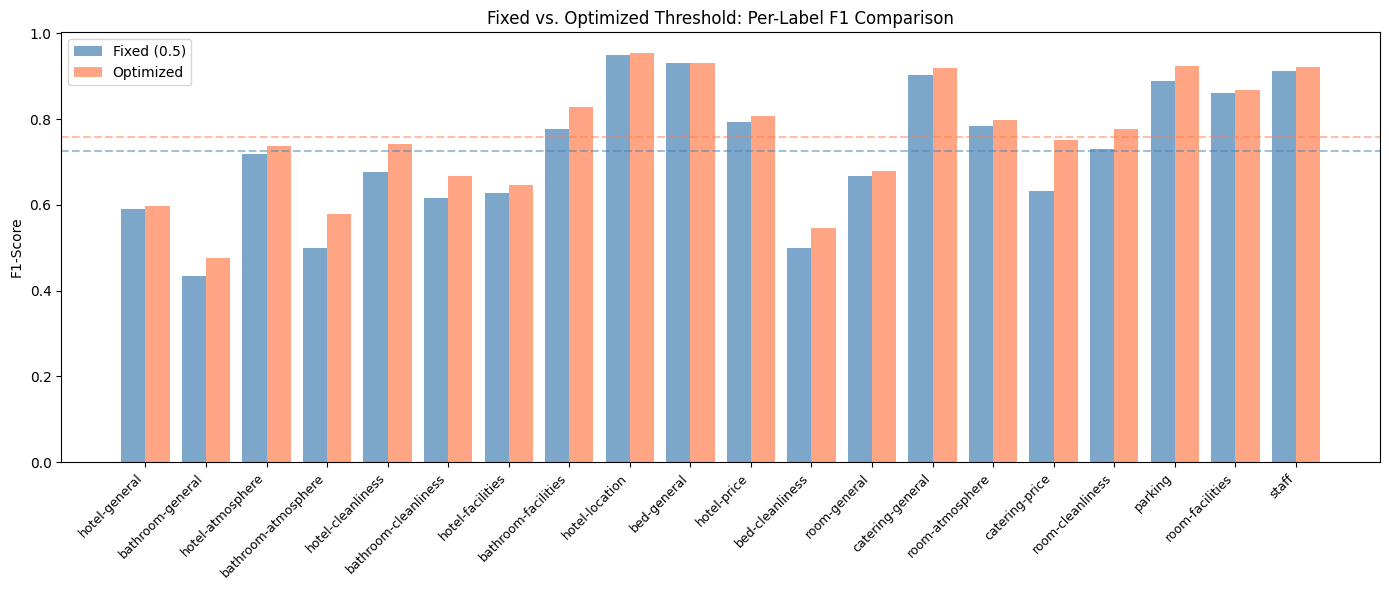

In [6]:
x = np.arange(len(label_list))
fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - 0.2, fixed_f1s, 0.4, label='Fixed (0.5)', alpha=0.7, color='steelblue')
ax.bar(x + 0.2, opt_f1s, 0.4, label='Optimized', alpha=0.7, color='coral')
ax.set_xticks(x)
ax.set_xticklabels(label_list, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('F1-Score')
ax.set_title('Fixed vs. Optimized Threshold: Per-Label F1 Comparison')
ax.legend()
ax.axhline(y=fixed_f1, color='steelblue', linestyle='--', alpha=0.5)
ax.axhline(y=optimal_f1, color='coral', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('threshold_comparison.png', dpi=150)
plt.show()